In [ ]:
import sys
sys.path.append('../')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from models.cdiff_lightning import LitCfgDiffusion
from utils.utils import encode_labels, position_encoding

from dataset.data_classes import PytorchSpectraDataset
from dataset.dataset_builder import SpectralDatasetBuilder

from attokit.templates.template_loader import paste_template

device = 'cpu'

In [2]:
cdiff = LitCfgDiffusion.load_from_checkpoint("../pretrained_models/weights_cdiff.ckpt")
cdiff.to(device)
cdiff.eval();

/u/nkerschb/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [ ]:
# Dataset Timespan
df = pd.read_parquet('../data/in-silico-gen-data.parquet')
df = pd.read_csv('../data/h4h_basic_data.csv')

t = []
for i, p in df.groupby('subject_id'):
    if len(p) >= 6:
        _t = pd.to_datetime(p['date_blood_collection']).max() - pd.to_datetime(p['date_blood_collection']).min()
        t.append(_t.days)
print(np.mean(t))


tmax = pd.to_datetime(df['date_blood_collection']).max() - pd.to_datetime(df['date_blood_collection']).min()
print(tmax.days)

In [3]:
dataset_builder = SpectralDatasetBuilder(data_path='../data/in-silico-gen-data.parquet', data_split={"train": 0.8, "test": 0.2}, config_path='../config.yaml')
dataset = PytorchSpectraDataset("../data/h4h_raw_2024-09-16_with_subject_ids.parquet")
column_names = dataset.df_test_scaled.iloc[:,:519].columns.values.astype(float)

In [4]:
df = dataset.df_train_normalized

In [7]:
peaks_for_peak_ratios = np.array([
1029.80810546875,
1045.23596191406,
1060.66381835938,
1079.94860839844,
1155.15930175781,
1170.58715820312,
1230.36999511719,
1238.083984375,
1240.01245117188,
1243.86938476562,
1313.29467773438,
1400.07629394531,
1450.21667480469,
1452.14514160156,
1515.78503417969,
1517.71350097656,
1538.9267578125,
1544.71228027344,
1546.64074707031,
1548.56921386719,
1550.49768066406,
1587.13879394531,
1635.35070800781,
1639.20776367187,
1654.63562011719,
1683.56274414062,
1739.48864746094,
1741.41711425781,
2850.29296875,
2852.22143554687,
2854.14990234375,
2871.50634765625,
2927.43212890625,
2931.2890625,
2958.28784179687,
2962.14477539063
])

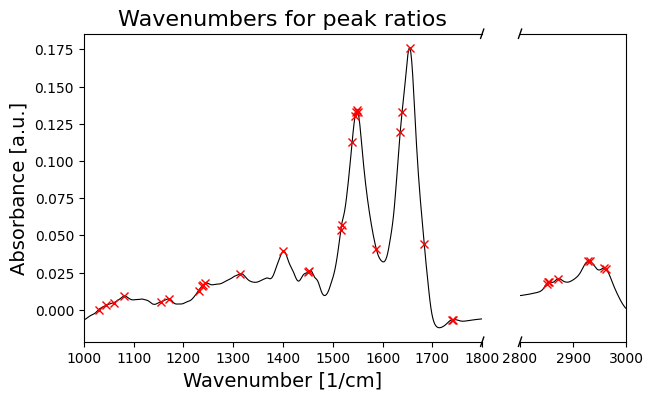

In [ ]:
s = df[column_names.astype(str)].mean()

x = column_names
spectrum = s.values

x_peaks = peaks_for_peak_ratios
peaks = s[peaks_for_peak_ratios.astype(str)].values

# setup figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4), width_ratios=[75, 20])

# plot spectrum
ax1.plot(x, spectrum, color='k', lw=0.8)
ax2.plot(x, spectrum, color='k', lw=0.8)

ax1.plot(x_peaks, peaks, color='r', lw=0.8, marker='x', linestyle='')
ax2.plot(x_peaks, peaks, color='r', lw=0.8, marker='x', linestyle='')

# set lims
ax1.set_xlim(1000,1800)
ax2.set_xlim(2800,3000)
#ax1.set_ylim(lower_lim, upper_lim)
#ax2.set_ylim(lower_lim, upper_lim)

ax1.tick_params(axis='y', colors='k')

ax1.grid(False)
ax2.grid(False)

ax1.set_title(f"Wavenumbers for peak ratios", fontsize=16)
ax1.set_ylabel('Absorbance [a.u.]', fontsize=14, color='k')
ax1.set_xlabel('Wavenumber [1/cm]', fontsize=14)

# Make the spacing between the two axes a bit smaller
plt.subplots_adjust(wspace=0.15)

d = .015 # how big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1-d*(20/75),1+d*(20/75)),(-d,+d), linewidth=1, **kwargs) # top-left diagonal
ax1.plot((1-d*(20/75),1+d*(20/75)),(1-d,1+d), linewidth=1, **kwargs) # bottom-left diagonal

kwargs.update(transform=ax2.transAxes) # switch to the bottom axes
ax2.plot((-d,d),(-d,+d), linewidth=1, **kwargs) # top-right diagonal
ax2.plot((-d,d),(1-d,1+d), linewidth=1, **kwargs) # bottom-right diagonal


ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.yaxis.tick_left()
ax2.yaxis.set_major_locator(ticker.NullLocator())

# Show plot
#plt.savefig('filename.pdf', bbox_inches='tight', dpi=300)
plt.savefig('wavenumbers_for_peak_ratios.png', bbox_inches='tight', dpi=300)
plt.show()


# Positional Encoding

In [3]:
test_dict = pd.DataFrame({
    'age': np.linspace(40, 80, 100),
    'sex': np.hstack([[0]*50, [1]*50]),
    'bmi': np.linspace(20, 35, 100),
})

In [4]:
cdiff = cdiff.to(device).eval() # Set model to evaluation mode
num_samples = len(test_dict)

test_dict = {
    col: torch.tensor(test_dict[col].values, device=device, dtype=torch.float32) 
    for col in ['sex', 'age', 'bmi']
}

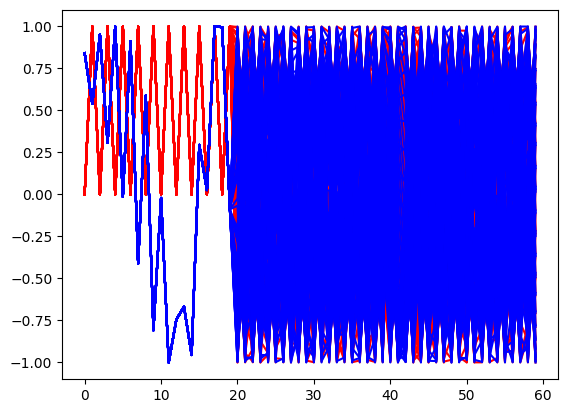

In [5]:
enc = encode_labels(test_dict, 20, device=device, pe_base=0.1).cpu().numpy()

plt.plot(enc[test_dict['sex']==0].T, color='r')
plt.plot(enc[test_dict['sex']==1].T, color='b')
plt.show()

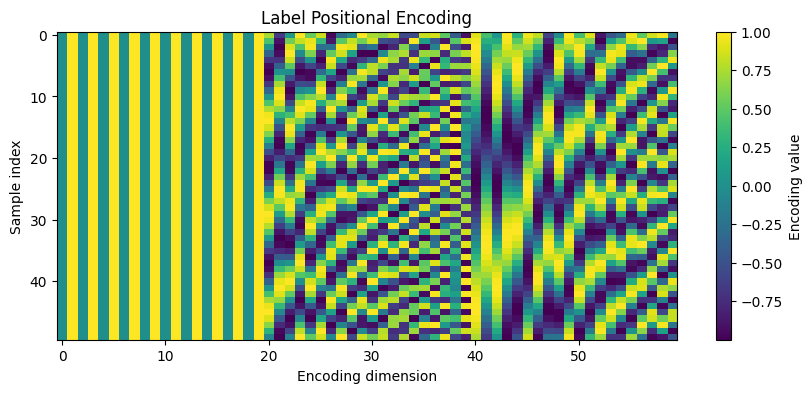

In [6]:
enc = encode_labels(test_dict, 20, device=device, pe_base=0.1).cpu().numpy()

plt.figure(figsize=(10, 4))
plt.imshow(enc[test_dict['sex']==0], aspect='auto', cmap='viridis')
plt.colorbar(label='Encoding value')
plt.xlabel("Encoding dimension")
plt.ylabel("Sample index")
plt.title("Label Positional Encoding")
plt.show()

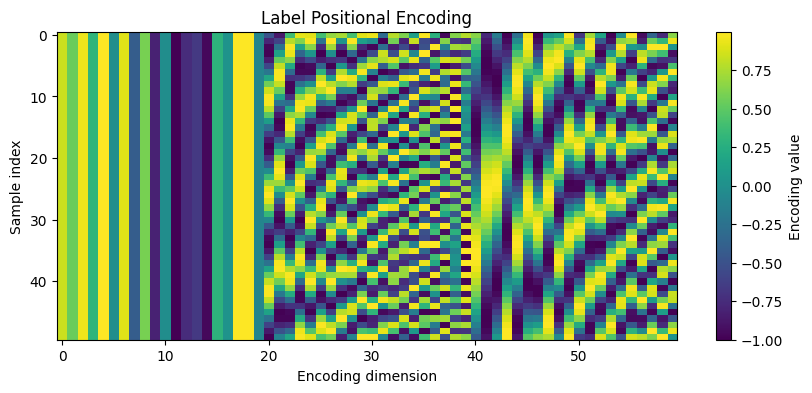

In [7]:
enc = encode_labels(test_dict, 20, device=device, pe_base=0.1).cpu().numpy()

plt.figure(figsize=(10, 4))
plt.imshow(enc[test_dict['sex']==1], aspect='auto', cmap='viridis')
plt.colorbar(label='Encoding value')
plt.xlabel("Encoding dimension")
plt.ylabel("Sample index")
plt.title("Label Positional Encoding")
plt.show()

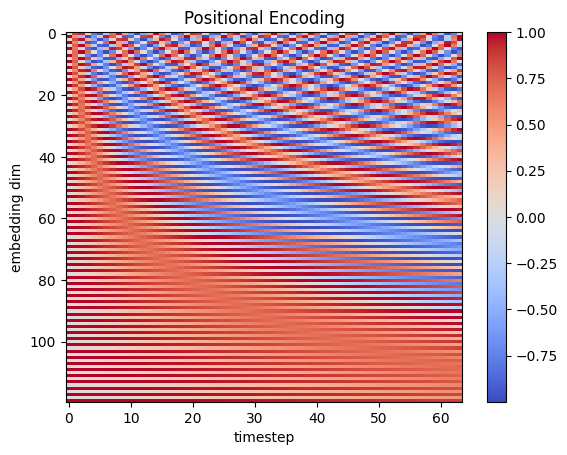

In [8]:
pe = position_encoding(
    torch.linspace(0,63,64),
    embedding_size=120,
    device=device,
    base=128
).cpu().numpy()

plt.imshow(pe.T, aspect="auto", cmap="coolwarm")
plt.xlabel("timestep")
plt.ylabel("embedding dim")
plt.colorbar()
plt.title("Positional Encoding")
plt.show()

# Diffusion Noise Schedule and Loss weight

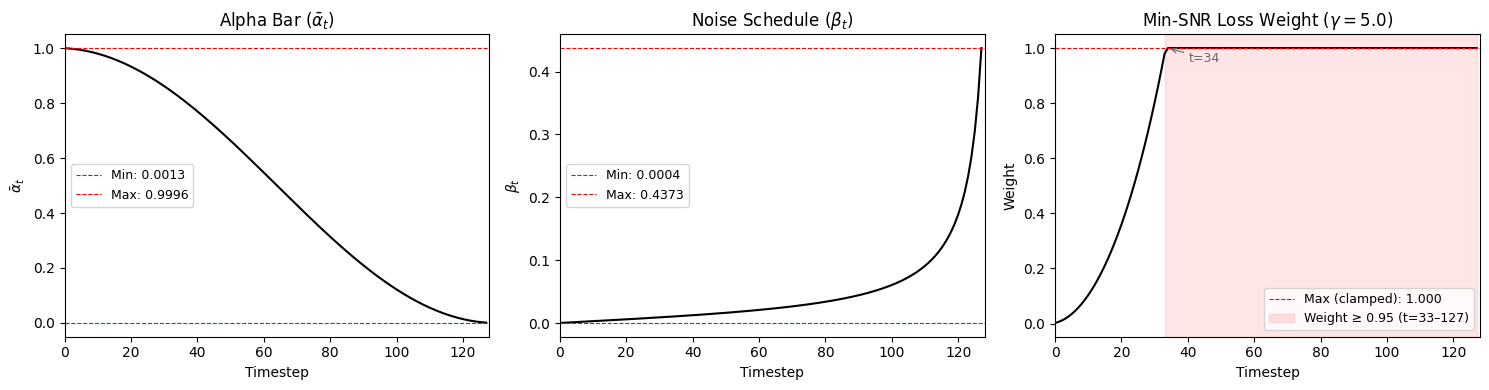

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

T = len(cdiff.alpha_bar.cpu().numpy())
timesteps = np.arange(T)
alpha_bar = cdiff.alpha_bar.cpu().numpy()
betas = cdiff.betas.cpu().numpy()
snr = cdiff.alpha_bar.cpu() / (1 - cdiff.alpha_bar.cpu())
gamma = 5.0
weight = torch.clamp(snr, max=gamma) / snr

# --- Alpha Bar ---
ax = axes[0]
ax.plot(timesteps, alpha_bar, color='k')
ax.set_title('Alpha Bar ($\\bar{\\alpha}_t$)')
ax.set_xlabel('Timestep')
ax.set_ylabel('$\\bar{\\alpha}_t$')
alpha_min = alpha_bar[-1]
alpha_max = alpha_bar[0]
ax.axhline(alpha_min, color='green', linestyle='--', linewidth=0.8, label=f'Min: {alpha_min:.4f}')
ax.axhline(alpha_max, color='red', linestyle='--', linewidth=0.8, label=f'Max: {alpha_max:.4f}')
ax.legend(fontsize=9, loc='center left')
ax.set_xlim(0, T)
ax.set_ylim(-0.05, 1.05)

# --- Beta ---
ax = axes[1]
ax.plot(timesteps, betas, color='k')
ax.set_title('Noise Schedule ($\\beta_t$)')
ax.set_xlabel('Timestep')
ax.set_ylabel('$\\beta_t$')
beta_min, beta_max = betas[0], betas[-1]
ax.axhline(beta_min, color='green', linestyle='--', linewidth=0.8, label=f'Min: {beta_min:.4f}')
ax.axhline(beta_max, color='red', linestyle='--', linewidth=0.8, label=f'Max: {beta_max:.4f}')
ax.legend(fontsize=9, loc='center left')
ax.set_xlim(0, T)

# --- Loss Weight ---
ax = axes[2]
weight_np = weight.numpy()
ax.plot(timesteps, weight_np, color='k')
ax.set_title(f'Min-SNR Loss Weight ($\\gamma={gamma}$)')
ax.set_xlabel('Timestep')
ax.set_ylabel('Weight')
weight_max_idx = np.argmax(weight_np)
ax.axhline(1.0, color='red', linestyle='--', linewidth=0.8, label=f'Max (clamped): {weight_np[weight_max_idx]:.3f}')
ax.annotate(f't={weight_max_idx}', xy=(weight_max_idx, weight_np[weight_max_idx]),
            xytext=(weight_max_idx + T*0.05, weight_np[weight_max_idx] - 0.05),
            fontsize=9, color='dimgray',
            arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8))
high_weight_threshold = 0.95
high_weight_idx = np.where(weight_np >= high_weight_threshold)[0]
if len(high_weight_idx) > 0:
    ax.axvspan(high_weight_idx[0], high_weight_idx[-1], alpha=0.1, color='red',
               label=f'Weight ≥ {high_weight_threshold} (t={high_weight_idx[0]}–{high_weight_idx[-1]})')
ax.legend(fontsize=9)
ax.set_xlim(0, T)

plt.tight_layout()
plt.savefig('CDIFF_noise_schedule.pdf', dpi=300)
plt.show()